In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

T_max, X_max = 1.0, 2.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("using", device)

using cuda


In [2]:
def grad(y,x):
    return torch.autograd.grad(
        y,x, grad_outputs = torch.ones_like(y), create_graph = True
    )[0]

In [3]:
def f_source(t, x):
    return (2*torch.sin(torch.exp(-t) * (1 - torch.cos(torch.pi*x)))
            - torch.pi**2 * torch.exp(-t) * torch.cos(torch.pi*x))

def u_exact_np(T, X):
    return np.exp(-T) * (1 - np.cos(np.pi*X))

In [4]:
class SineGordonPINN(nn.Module):
    def __init__(self, width = 64, depth = 4):
        super().__init__()
        layers = [nn.Linear(2,width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width,width), nn.Tanh()]
        layers += [nn.Linear(width,1)]
        self.net = nn.Sequential(*layers)

    def forward(self,t,x):

        nn_out = self.net(torch.cat([t,x],dim=1))

        lift  = (1 - t) * (1 - torch.cos(torch.pi * x))
        term2 = (t ** 2) * x * (X_max - x) * nn_out

        return lift + term2

In [5]:
N,M = 256,128
t_lin = torch.linspace(0, T_max, N)
x_lin = torch.linspace(0, X_max, M)
T_grid,X_grid = torch.meshgrid(t_lin, x_lin, indexing='ij')

t_col = T_grid.reshape(-1, 1).to(device).requires_grad_(True)
x_col = X_grid.reshape(-1, 1).to(device).requires_grad_(True)

print(t_col.shape)

torch.Size([32768, 1])


In [6]:
model = SineGordonPINN(width = 64, depth = 4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.5)

def compute_loss():
    u = model(t_col,x_col)
    u_t = grad(u, t_col)
    u_tt = grad(u_t, t_col)
    u_x = grad(u, x_col)
    u_xx = grad(u_x, x_col)

    residual = u_tt - u_xx + u_t + 2*torch.sin(u) - f_source(t_col, x_col)

    return (residual**2).mean()

In [7]:
import time

torch.cuda.synchronize()
t0 = time.time()
losses = []

for epoch in range(5000):
    optimizer.zero_grad()
    loss = compute_loss()
    loss.backward()
    optimizer.step()
    scheduler.step()
    if epoch % 50 == 0:
        losses.append(loss.item())
    if epoch % 500 == 0:
        print(f"epoch {epoch:5d}  loss {loss.item():.3e}")

torch.cuda.synchronize()
pinn_time = time.time()-t0
print(f"trained in {pinn_time:.1f}s")

epoch     0  loss 8.322e+00
epoch   500  loss 1.496e-03
epoch  1000  loss 7.597e-04
epoch  1500  loss 5.226e-04
epoch  2000  loss 3.531e-04
epoch  2500  loss 2.926e-04
epoch  3000  loss 2.472e-04
epoch  3500  loss 2.281e-04
epoch  4000  loss 2.096e-04
epoch  4500  loss 2.001e-04
trained in 90.9s


In [8]:
# LBFGS can occasionally produce NaN weights. Keep a copy of the good ones.
adam_weights = {name: tensor.detach().clone()
                for name, tensor in model.state_dict().items()}

lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr               = 1.0,
    max_iter         = 3000,
    max_eval         = 4000,
    history_size     = 50,
    tolerance_grad   = 1e-9,
    tolerance_change = 1e-11,
    line_search_fn   = 'strong_wolfe'
)

lbfgs_losses = []          # loss at every evaluation, for the loss curve later

def closure():
    lbfgs.zero_grad()

    loss = compute_loss()
    loss.backward()

    lbfgs_losses.append(loss.item())
    if len(lbfgs_losses) % 200 == 0:
        print(f"  eval {len(lbfgs_losses):5d}   loss {loss.item():.3e}")

    return loss

torch.cuda.synchronize()
t0 = time.time()

lbfgs.step(closure)          # this single call is the whole optimisation

torch.cuda.synchronize()
lbfgs_time = time.time() - t0

final_loss = compute_loss().item()
print(f"LBFGS: {len(lbfgs_losses)} evals in {lbfgs_time:.1f}s")
print(f"final loss {final_loss:.3e}")

if not np.isfinite(final_loss):
    model.load_state_dict(adam_weights)
    print("diverged to NaN - rolled back to the Adam weights")

    

  eval   200   loss 8.126e-06
LBFGS: 317 evals in 9.9s
final loss 1.242e-06


In [9]:
with torch.no_grad():
    tt = torch.linspace(0, T_max, 200).reshape(-1, 1)
    xx = torch.linspace(0, X_max, 100).reshape(-1, 1)
    TT, XX = torch.meshgrid(tt.flatten(), xx.flatten(), indexing='ij')
    t_ev = TT.reshape(-1, 1).to(device)
    x_ev = XX.reshape(-1, 1).to(device)
    u_pred = model(t_ev, x_ev).reshape(200, 100).cpu().numpy()

u_exact = u_exact_np(TT.numpy(), XX.numpy())

pinn_err = np.abs(u_pred - u_exact).max()
rel_l2   = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
print(f"PINN max error: {pinn_err:.3e}   rel-L2: {rel_l2:.3e}")

PINN max error: 6.452e-05   rel-L2: 2.237e-05


In [ ]:
class SineGordonSplitPINN(nn.Module):
    """
    Two unknowns

    u_hat = (1-t)(1-cos(pi x))  +  t^2 * x(2-x) * N_1(t,x)
    v_hat = -(1-t)(1-cos(pi x)) +  t   * x(2-x) * N_2(t,x)

    u_hat  satisfies  u(x,0)=g0,  u_t(x,0)=g1,  u(0,t)=u(2,t)=0
    v_hat  satisfies  v(x,0)=g1,               v(0,t)=v(2,t)=0
    """
    def __init__(self, width = 64, depth = 4):
        super().__init__()
        layers = [nn.Linear(2,width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width,width), nn.Tanh()]
        layers += [nn.Linear(width,2)]          # two outputs now, not one
        self.net = nn.Sequential(*layers)

    def forward(self,t,x):

        nn_out = self.net(torch.cat([t,x],dim=1))
        n1 = nn_out[:, 0:1]                     # slice, not index, to keep shape (N,1)
        n2 = nn_out[:, 1:2]

        wall = x * (X_max - x)                  # zero at both boundaries
        shape = 1 - torch.cos(torch.pi * x)     # zero at both boundaries too

        u_hat = (1 - t) * shape + (t ** 2) * wall * n1
        v_hat = -(1 - t) * shape +  t      * wall * n2

        return u_hat, v_hat

In [11]:
torch.manual_seed(0)                            # same seed as the direct run

model_split = SineGordonSplitPINN(width = 64, depth = 4).to(device)
optimizer_split = torch.optim.Adam(model_split.parameters(), lr=1e-3)
scheduler_split = torch.optim.lr_scheduler.StepLR(optimizer_split, step_size=1000, gamma=0.5)

def compute_loss_split():
    u, v = model_split(t_col, x_col)

    u_t  = grad(u, t_col)
    u_x  = grad(u, x_col)
    u_xx = grad(u_x, x_col)
    v_t  = grad(v, t_col)

    res_1 = u_t - v
    res_2 = v_t - u_xx + v + 2*torch.sin(u) - f_source(t_col, x_col)

    return (res_1**2).mean() + (res_2**2).mean()

In [12]:
torch.cuda.synchronize()
t0 = time.time()
losses_split = []

for epoch in range(5000):
    optimizer_split.zero_grad()
    loss = compute_loss_split()
    loss.backward()
    optimizer_split.step()
    scheduler_split.step()
    if epoch % 50 == 0:
        losses_split.append(loss.item())
    if epoch % 500 == 0:
        print(f"epoch {epoch:5d}  loss {loss.item():.3e}")

torch.cuda.synchronize()
split_adam_time = time.time()-t0
print(f"trained in {split_adam_time:.1f}s")

epoch     0  loss 1.756e+00
epoch   500  loss 1.641e-03
epoch  1000  loss 5.771e-04
epoch  1500  loss 2.787e-04
epoch  2000  loss 1.505e-04
epoch  2500  loss 1.185e-04
epoch  3000  loss 9.563e-05
epoch  3500  loss 8.594e-05
epoch  4000  loss 7.637e-05
epoch  4500  loss 7.136e-05
trained in 71.7s


In [13]:
adam_weights_split = {name: tensor.detach().clone()
                      for name, tensor in model_split.state_dict().items()}

lbfgs_split = torch.optim.LBFGS(
    model_split.parameters(),
    lr               = 1.0,
    max_iter         = 3000,
    max_eval         = 4000,
    history_size     = 50,
    tolerance_grad   = 1e-9,
    tolerance_change = 1e-11,
    line_search_fn   = 'strong_wolfe'
)

lbfgs_losses_split = []

def closure_split():
    lbfgs_split.zero_grad()
    loss = compute_loss_split()
    loss.backward()
    lbfgs_losses_split.append(loss.item())
    if len(lbfgs_losses_split) % 200 == 0:
        print(f"  eval {len(lbfgs_losses_split):5d}   loss {loss.item():.3e}")
    return loss

torch.cuda.synchronize()
t0 = time.time()
lbfgs_split.step(closure_split)
torch.cuda.synchronize()
split_lbfgs_time = time.time() - t0

final_split = compute_loss_split().item()
print(f"LBFGS: {len(lbfgs_losses_split)} evals in {split_lbfgs_time:.1f}s")
print(f"final loss {final_split:.3e}")

if not np.isfinite(final_split):
    model_split.load_state_dict(adam_weights_split)
    print("diverged to NaN - rolled back to the Adam weights")

  eval   200   loss 1.056e-05
  eval   400   loss 2.204e-06
  eval   600   loss 6.981e-07
LBFGS: 632 evals in 17.0s
final loss 6.820e-07


In [14]:
def v_exact_np(T, X):
    return -np.exp(-T) * (1 - np.cos(np.pi*X))

with torch.no_grad():
    u_p, v_p = model_split(t_ev, x_ev)
    u_pred_split = u_p.reshape(200, 100).cpu().numpy()
    v_pred_split = v_p.reshape(200, 100).cpu().numpy()

v_exact = v_exact_np(TT.numpy(), XX.numpy())

split_err     = np.abs(u_pred_split - u_exact).max()
split_rel_l2  = np.linalg.norm(u_pred_split - u_exact) / np.linalg.norm(u_exact)
split_err_v   = np.abs(v_pred_split - v_exact).max()

print(f"split  u:  max error {split_err:.3e}   rel-L2 {split_rel_l2:.3e}")
print(f"split  v:  max error {split_err_v:.3e}")

split  u:  max error 1.834e-04   rel-L2 7.799e-05
split  v:  max error 2.103e-03


## Observations

Both formulations share everything except the formulation itself: same trunk
(4 x 64, tanh), same 256 x 128 collocation grid, same seed, same Adam budget
(5000 epochs, lr 1e-3 halved every 1000), same LBFGS settings, same evaluation
grid. All conditions hard-embedded, so both losses are PDE residuals only.

### Results (seed 0)

| | max error $u$ | rel-$L^2$ $u$ | Adam | LBFGS |
|---|---|---|---|---|
| direct | 6.452e-05 | 2.237e-05 | 90.9 s | 9.9 s, 317 evals |
| split | 1.834e-04 | 7.799e-05 | 71.7 s | 17.0 s, 632 evals |

Direct is ~3.5x more accurate. Split is ~21% cheaper per Adam epoch, because its
residuals need only one nested derivative ($u_x \to u_{xx}$) where the direct
residual needs two ($u_x \to u_{xx}$ and $u_t \to u_{tt}$).

Adam alone reached rel-$L^2$ 9.05e-04 on the direct problem; LBFGS took it to
2.24e-05.

### Caveats

1. Single seed — the 3.5x gap is not established.
2. Fragile to hyperparameters. Adding the LR scheduler helped split (its Adam
   loss had been spiking) but hurt direct (already monotone), moving the gap
   from 7x to 3.5x.
3. The two loss values are not comparable — direct is one residual, split is a
   sum of two. Only errors against the exact solution are.
4. $\hat v$'s error (2.10e-03) is 10x worse than $\hat u$'s despite $v = -u$
   here. Not investigated.

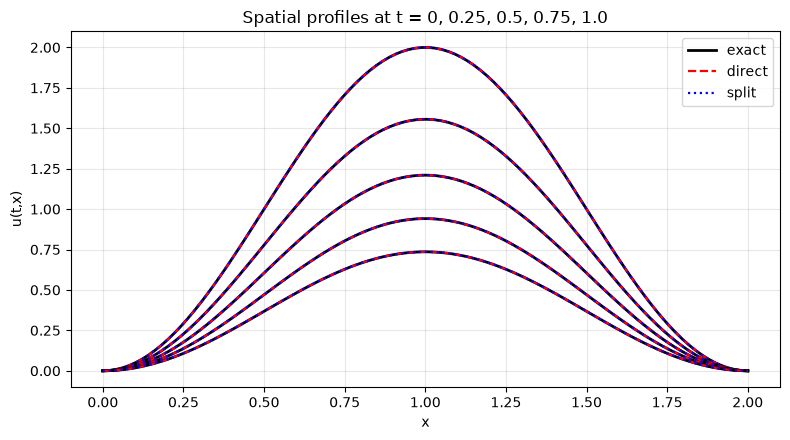

In [16]:
x_np = xx.numpy().flatten()
t_np = tt.numpy().flatten()

plt.figure(figsize=(8, 4.5))
for k, ti in enumerate([0, 50, 100, 150, 199]):
    plt.plot(x_np, u_exact[ti], 'k-', lw=2, label='exact' if k==0 else None)
    plt.plot(x_np, u_pred[ti], 'r--', lw=1.6, label='direct' if k==0 else None)
    plt.plot(x_np, u_pred_split[ti], 'b:', lw=1.6, label='split' if k==0 else None)
plt.xlabel('x'); plt.ylabel('u(t,x)')
plt.title('Spatial profiles at t = 0, 0.25, 0.5, 0.75, 1.0')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

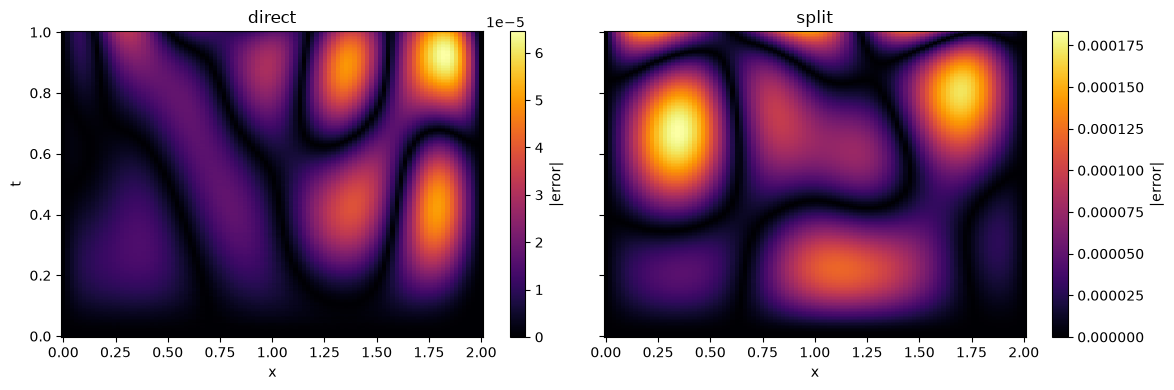

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for a, err, ttl in zip(ax,
                       [np.abs(u_pred - u_exact), np.abs(u_pred_split - u_exact)],
                       ['direct', 'split']):
    c = a.pcolormesh(x_np, t_np, err, shading='auto', cmap='inferno')
    fig.colorbar(c, ax=a, label='|error|')
    a.set_xlabel('x'); a.set_title(ttl)
ax[0].set_ylabel('t')
plt.tight_layout(); plt.show()